In this tutorial, we demonstrate a time-series modeling based on reservoir computing and its optimization methods by using the logistic map as a target time-series to model.

More specifically, we will cover
* how to train a reservoir network to predict a time-series of a toy system, the logistic map.
* how to optimize a reservoir network to forecast long-term behavior of the logistic map.
* how to infer ergodic properties (Lyapunov exponent) of the logistic map using the optimized reservoir.

References:

[1] Kawano, A., Soroka, I., Stephens, G.J., n.d. Optimizing Reservoir Computing for Reconstructing Ergodic Properties.

We use the logistic map, 1D discrete dynamical system, as a simple toy system to illustrate our method. Let's simulate the logistic map, $$x_{n+1}=rx_n(1-x_n),$$
with $r=4$ which exhibits fullly chatic behavior.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 20})
from numpy.linalg import pinv, qr
# from scipy.linalg import pinv, qr
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


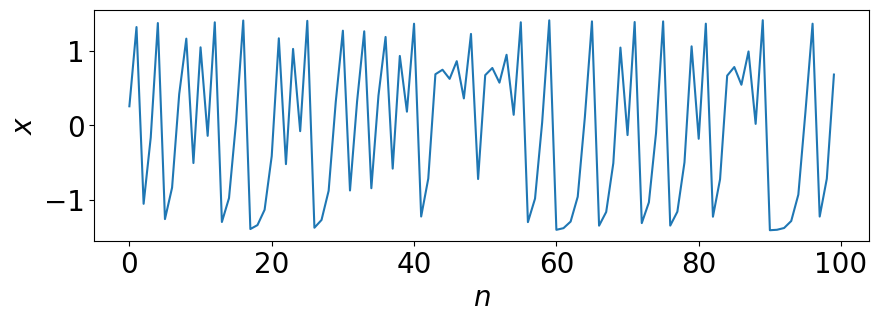

In [2]:
def logistic_map(r, x0, T, tT=0):
    N = T + tT
    x = np.empty(N + 1)
    x[0] = x0
    for n in range(N):
        x[n+1] = r * x[n] * (1 - x[n])
    return x[tT+1:]  # discard transient

# Parameters
r = 4.
x0 = 0.2
T = 80000
tT = 20

y = logistic_map(r, x0, T, tT)

# Normarize time-series
input = (y - np.mean(y)) / np.std(y)
input= input.reshape(-1, 1)

plt.figure(figsize=[10,3])
plt.plot(input[:100, 0])
plt.ylabel('$x$')
plt.xlabel('$n$')
plt.show()


We aim to model this time-series (meaning identifying important dynamical properties) using reservoir computing. First step is to prepare a reservoir as a randomly connected neural network $r$. Reservoir's properties can be specified by the following update rule,
$$\vec{r}_{t+1} = \tanh\left( {W}_r \vec{r}_t + {W}_{in} x_t + \vec b \right).$$
where $\vec{r}_t$ is the instantaneous activity across all $N$ nodes of the network, $x_t$ is an m-dimensional input, $W_r$ is a $N \times N$ connectivity matrix, $W_i$ is an $N \times m$ input matrix, and $\vec{b}$ is an N-dimensional bias. We choose the elements of the matrix $W_r$ by randomly sampling from a normal distribution $\mathcal{N}(0, g)$. We choose the elements of the matrix $W_i$ and the bias $\vec{b}$ by randomly sampling from a normal distribution $\mathcal{N}(0, 1)$.

An interpretation of this equation is that we drive a randomly connected network $r$ via out input time-series $x$.

In [3]:
seed = 5
np.random.seed(seed)

N = 100
M = input.shape[1]
g = 1./N
gi = 1.
gb = 1.

Wr = g * np.random.randn(N, N)
Win = gi * np.random.randn(N, M)
b = gb * np.random.randn(N, 1)

Here, we initialized a reservoir with 100 nodes and sampled a connectivity matrix from $\mathcal{N}(0, N^{-1})$ and other matrices from $\mathcal{N}(0, 1)$. Next, we drive the reservoir via our input time-series.

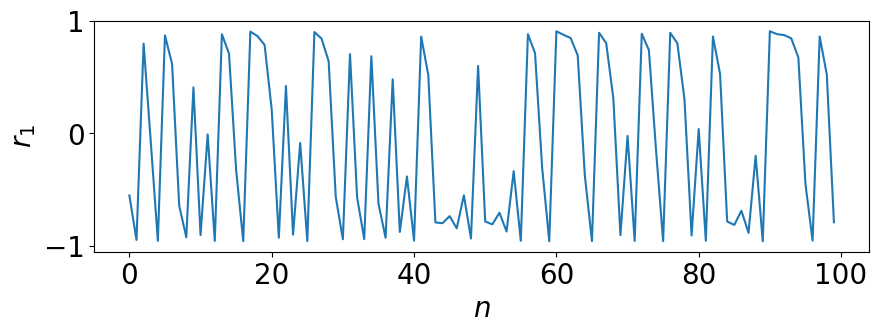

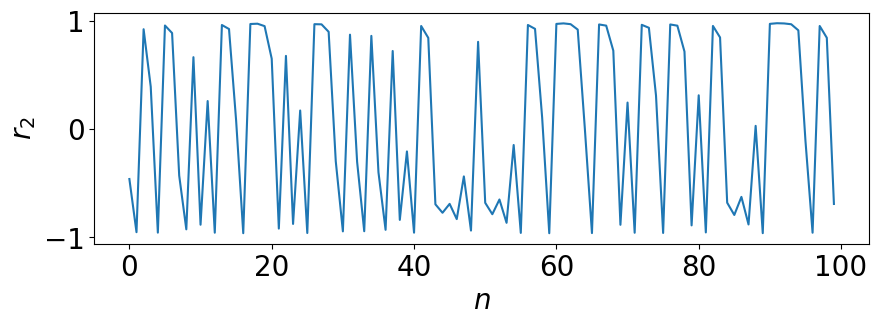

In [4]:
xtrain = input[:int(np.floor(input.shape[0]/2)), :] # get first half
xtest = input[int(np.floor(input.shape[0]/2)):, :] # get last half

r = np.random.randn(N, 1) # initial value of r

train_length = xtrain.shape[0]
rs = np.zeros((N, train_length))
for i in range(train_length):
    r = np.tanh(Wr @ r + Win @ xtrain[i, :].reshape(-1, 1) + b)
    rs[:, i] = r.flatten()

plt.figure(figsize=[10,3])
plt.plot(rs[0,:100])
plt.ylabel('$r_1$')
plt.xlabel('$n$')
plt.show()
plt.figure(figsize=[10,3])
plt.plot(rs[1,:100])
plt.ylabel('$r_2$')
plt.xlabel('$n$')
plt.show()

We plotted 100 steps dynamics of the first and second nodes of the reservoir. A key idea is that this reservoir's response to the input must encode the information of the logstic map dynamics. We thus construct $W_o$, a linear map $\vec r_{t+1}\to x_{t+1}$, using ridge regression.

In [5]:
warmup = 1000  # step when a hidden state converges
Wo = xtrain[warmup:, :].T @ pinv(rs[:, warmup-1:-1]) # ridge regression

We are now able to predict one-step future value of the input. Note that the learning of reservoir computing is so handy! By using this prediction, we can recursively perform predictions and forcast a future trajectory of the input. An important step here is that we can construct an autonomous reservoir dynamics by substituting the predicted input $W_o\vec r_{t+1}= \hat x_{t+1}$ to the reservoir's update rule,
$$\vec{r}_{t+1} = \tanh\left( {W}_r \vec{r}_t + {W}_{in} W_o \vec r_t + \vec b \right).$$


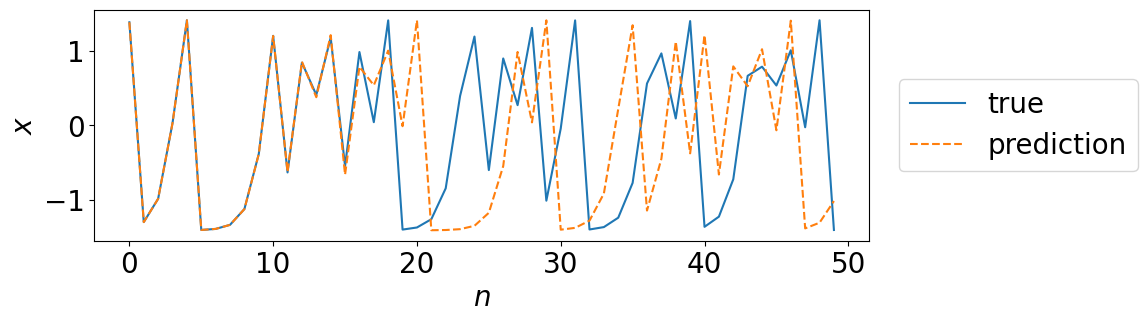

In [6]:
prednum = 50
preds = np.zeros((M, prednum))
r = np.random.randn(N, 1)

for i in range(warmup):
    r = np.tanh(Wr @ r + Win @ xtest[i, :].reshape(-1, 1) + b)

pred = Wo @ r

for i in range(prednum):
    r = np.tanh(Wr @ r + Win @ pred + b)
    pred = Wo @ r
    preds[:, i] = pred.flatten()

plt.figure(figsize=[10,3])
plt.plot(xtest[warmup+1:prednum+warmup+1],label='true')
plt.plot(preds[0],'--',label='prediction')
plt.xlabel('$n$')
plt.ylabel('$x$')
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.show()

The prediction was valid until around $n=18$. As the input dynamics is chaotic, the prediction fails eventually, however, the behavior look similar to the input even after the failure of prediction. This replication of long-term behavior (a.k.a. climate) is an important phenomena (also a challenging aspect) of reservoir computing. Let's examine climate of our reservoir by predicting a long trajectory.

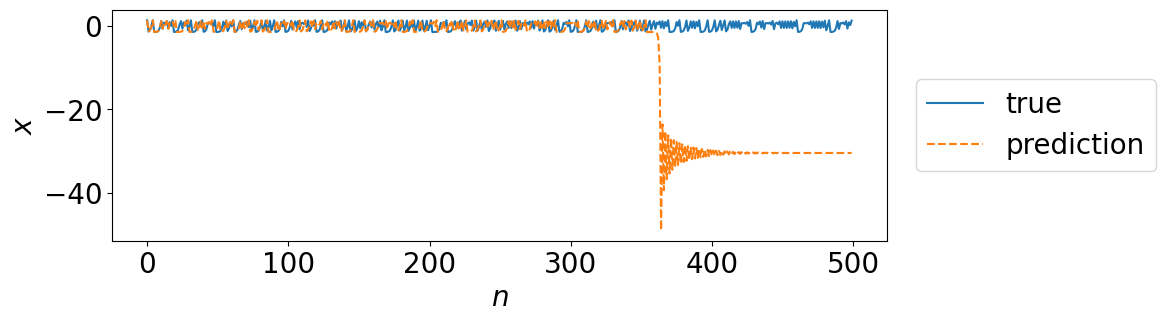

In [7]:
prednum = 500
preds = np.zeros((M, prednum))
r = np.random.randn(N, 1)

for i in range(warmup):
    r = np.tanh(Wr @ r + Win @ xtest[i, :].reshape(-1, 1) + b)

pred = Wo @ r

for i in range(prednum):
    r = np.tanh(Wr @ r + Win @ pred + b)
    pred = Wo @ r
    preds[:, i] = pred.flatten()

plt.figure(figsize=[10,3])
plt.plot(xtest[warmup+1:prednum+warmup+1],label='true')
plt.plot(preds[0],'--',label='prediction')
plt.xlabel('$n$')
plt.ylabel('$x$')
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.show()

This time, we predicted a longer ($n=500$) trajectory. The reservoir's prediction largely deviated from the true behavior at around $n=380$, suggesting that this reservoir can not model climate of the logistic map correctly. This long term behavior is sensitive to reservoir's hyperparameters such as the variance of sample distribution of connection matrix $g$.

Our next objective is to find good hyper-parameters of a reservoir and achieve a correct climate prediction.

Our optimization approach focuses on the reconstruction of invariant density (stationary distribution) of our input time-series. Let's compare invariant densities between the logistic map and the prediction from our reservoir.

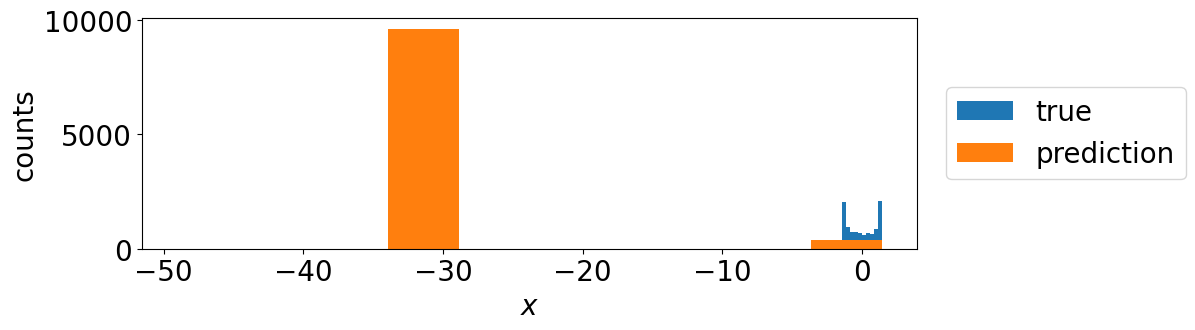

In [8]:
prednum = 10**4
preds = np.zeros((M, prednum))
r = np.random.randn(N, 1)

for i in range(warmup):
    r = np.tanh(Wr @ r + Win @ xtest[i, :].reshape(-1, 1) + b)

pred = Wo @ r

for i in range(prednum):
    r = np.tanh(Wr @ r + Win @ pred + b)
    pred = Wo @ r
    preds[:, i] = pred.flatten()

plt.figure(figsize=[10,3])
plt.hist(xtest[warmup+1:prednum+warmup+1],label='true')
plt.hist(preds[0],label='prediction')
plt.ylabel('counts')
plt.xlabel('$x$')
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.show()

We quantify the prediction error in the invariant density by measuring the statistical deference $D(P_\mathrm{true}||P_\mathrm{prediction})$. Specifically we adopt the Kolmogorov-Smirnov distance $D_\mathrm{KS}$ for 1D input time-series and the sliced Wasserstein distance $D_\mathrm{SW}$ for multivariate input [1].

Let's calculate $D_\mathrm{KS}$ of the above true and predicted invariant densities.

In [11]:
dks = stats.ks_2samp(xtrain.reshape([-1]), preds.T[0]).statistic
print('D_KS: ',dks)

D_KS:  0.936275


$D_\mathrm{KS}$ is bounded between $0$ and $1$, and thus the obtained value, $0.9$, is a large distance, meaning the predicted distribution is far from the true distribution.

Next we aim to find good hyper-parameters that lead to correct climate with small $D_\mathrm{KS}$. For a simple dynamics, we can focus only on major parameters such as the number of nodes $N$ and the variance of the connectivity matrix $g$ and fix other parameters to typical value. In such a case, we can perform a grid search on the simple parameter space to find optimal parameters. For a more complex dynamics such as real biological data, we might need to optimize all parameters by a more efficient optimization such as Bayesian optimization method [1].

For this demonstration, we fix the sample variance for $W_{in}$ and $\vec{b}$ to be $1$, and we perform a grid search by measuring $D_\mathrm{KS}$ across the number of nodes $N$ and the spectral radius of the connectivity matrix $\rho$.

N: 1
N: 2
N: 6
N: 15
N: 39
N: 100


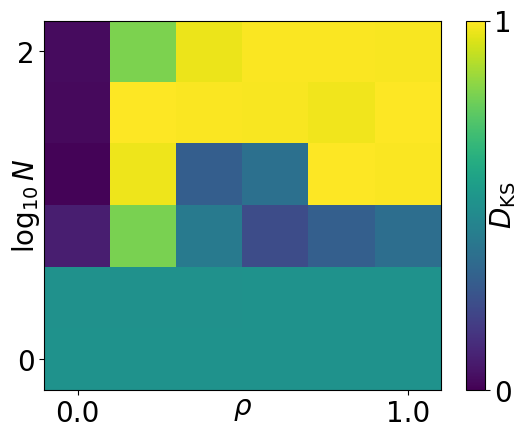

In [13]:
def spectral_radius(A):
    eigenvalues = np.linalg.eigvals(A)
    return np.max(np.abs(eigenvalues))

dN = .4
Nlist = 10.**np.arange(0, 2 + dN, dN)
dsr = 0.2
srlist = np.arange(0.0, 1 +dsr, dsr)

distmtx = np.zeros((len(Nlist), len(srlist)))
ctL = 0
for N in Nlist:
    N = int(N)
    print(f"N: {N}")
    cth = 0
    for sr_set in srlist:
        seed = 0
        np.random.seed(seed)
        dists = []
        for i in range(4):
            gi = 1.
            gb = 1.
            Wr = np.random.randn(N, N)
            sr = spectral_radius(Wr)
            Wr = sr_set*Wr*(sr)**-1
            Wi = gi * np.random.randn(N, M)  # input-to-hidden
            b = gb * np.random.randn(N, 1)  # hidden bias
            # training
            trainnum = xtrain.shape[0]
            rs= np.zeros((N, trainnum))
            r = np.random.rand(N, 1)
            for i in range(trainnum):
                r = np.tanh(Wr @ r + Wi @ xtrain[i, :].reshape(-1, 1) + b)
                rs[:, i] = r.flatten()
            Wo = xtrain[warmup:, :].T @ pinv(rs[:, warmup-1:-1])
            if np.isnan(Wo).any():
                continue
            # invariant dist test
            prednum = 10**4
            preds = np.zeros((1, prednum))
            r = np.random.rand(N, 1)
            for i in range(warmup):
                r = np.tanh(Wr @ r + Wi @ xtest[i, :].reshape(-1, 1) + b)
            pred = Wo @ r
            for i in range(prednum):
                r = np.tanh(Wr @ r + Wi @ pred + b)
                pred = Wo @ r
                preds[:, i] = pred.flatten()
            dists.append(stats.ks_2samp(xtrain.reshape([-1]), preds[0]).statistic)
        distmtx[ctL, cth] = np.median(dists)
        cth += 1
    ctL += 1
plt.figure()
img = plt.imshow(distmtx, aspect='auto',vmin=0,vmax=1)
cbar = plt.colorbar(img)
cbar.set_ticks([0, 1])             # set custom tick positions
cbar.set_label('$D_\mathrm{KS}$', labelpad=-17)   # adjust padding
plt.ylabel('$\log_{10} N$', labelpad=-18)
plt.xlabel('$\\rho$', labelpad=-24)
plt.xticks([0, len(srlist) - 1], [srlist[0], "{:.1f}".format(srlist[-1])])
plt.yticks([0, len(Nlist) - 1], ["{:.0f}".format(np.log10(Nlist[0])), "{:.0f}".format(np.log10(Nlist[-1]))])
plt.gca().invert_yaxis()
plt.show()

We observed that reservoir networks with $N>6$ and $\rho=0$ shows $D_\mathrm{KS}\simeq 0$, suggesting that they predicts invariant density correctly. Let's take a look at
 the performance of a network with $N=100$ and $\rho=0$.

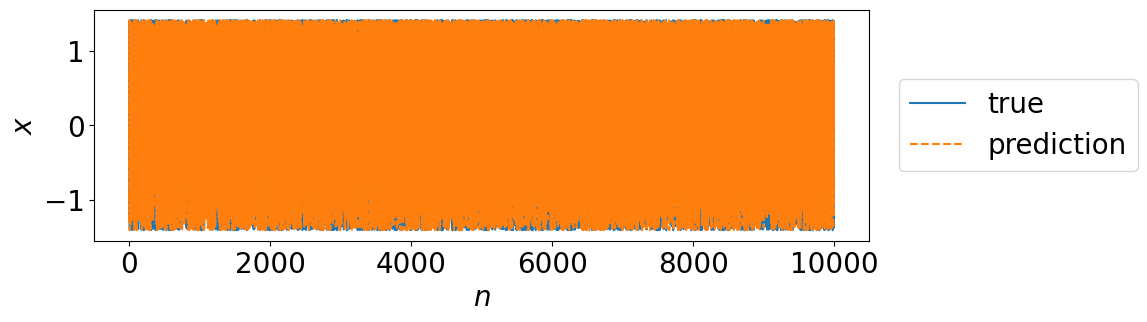

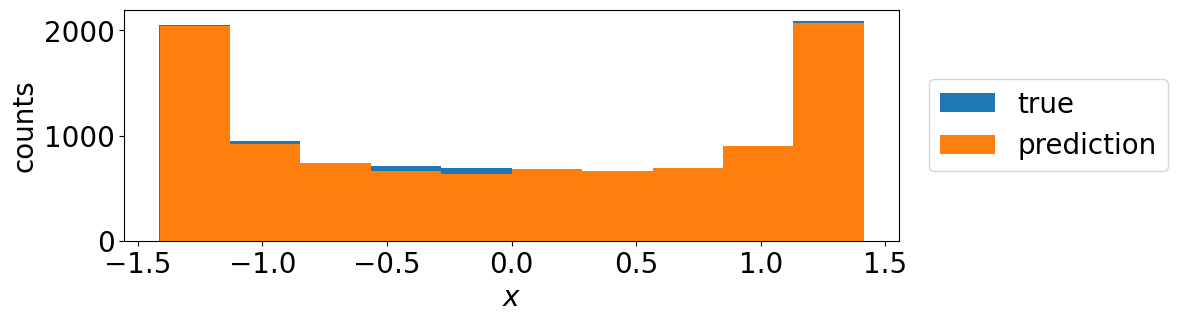

D_KS:  0.009125


In [14]:
seed = 0
np.random.seed(seed)
N = 100
sr_set = 0.
gi = 1.
gb = 1.
Wr = np.random.randn(N, N)
sr = spectral_radius(Wr)
Wr = sr_set*Wr*(sr)**-1
Wi = gi * np.random.randn(N, M)
b = gb * np.random.randn(N, 1)

trainnum = xtrain.shape[0]
rs= np.zeros((N, trainnum))
r = np.random.rand(N, 1)
for i in range(trainnum):
    r = np.tanh(Wr @ r + Wi @ xtrain[i, :].reshape(-1, 1) + b)
    rs[:, i] = r.flatten()
Wo = xtrain[warmup:, :].T @ pinv(rs[:, warmup-1:-1])

prednum = 10**4
preds = np.zeros((1, prednum))
r = np.random.rand(N, 1)
for i in range(warmup):
    r = np.tanh(Wr @ r + Wi @ xtest[i, :].reshape(-1, 1) + b)
pred = Wo @ r
for i in range(prednum):
    r = np.tanh(Wr @ r + Wi @ pred + b)
    pred = Wo @ r
    preds[:, i] = pred.flatten()

plt.figure(figsize=[10,3])
plt.plot(xtest[warmup+1:prednum+warmup+1],label='true')
plt.plot(preds[0],'--',label='prediction')
plt.xlabel('$n$')
plt.ylabel('$x$')
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.show()

plt.figure(figsize=[10,3])
plt.hist(xtest[warmup+1:prednum+warmup+1],label='true')
plt.hist(preds[0],label='prediction')
plt.ylabel('counts')
plt.xlabel('$x$')
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.show()

print('D_KS: ',stats.ks_2samp(xtrain.reshape([-1]), preds[0]).statistic)

The predicted invariant density is almost identical to the original, resulting $D_{KS}=0$. Therefore, this network successfully learn climate of the logistic map.

A powerful application of reservoir computing is that we can infer ergodic properties (properties that characterize long term behavior) of the input dynamics from the network. The trained network synchronize to the input dynamics and copy its ergodic properties (see [1] and references in it).

Here, we calculate Lyapunov exponents of the autonomous reservoir network.

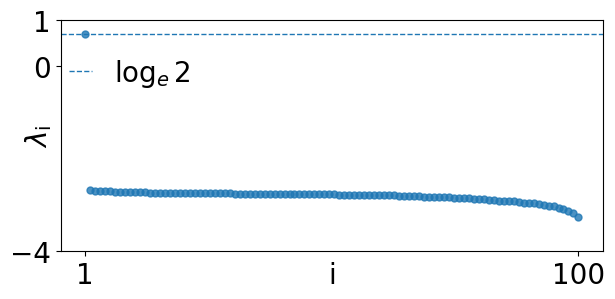

In [15]:
def jac_reservoir(r, Wo, Wi, Wr, b):
    '''
    The jacobian of reservoir.
    '''
    A = Wr + Wi @ Wo
    Ar = A @ r + b
    sech2 = 1 / np.cosh(Ar)**2
    jac = A * sech2
    return jac
# Forward transient
n0 = int(15) #int(15/dt)  # steps for transient
k = 10  # sampling step
G = np.random.rand(N, N)
G, _ = qr(G)
for i in range(n0//k):
    for j in range(k):
        J = jac_reservoir(rs.T[k*i + j, :].reshape(-1, 1), Wo, Wi, Wr, b)
        G = J @ G
    G, R = qr(G)  # QR decomposition
# Forward dynamics
t0 = n0
t = prednum - n0 - t0  # int(T/2/dt) - n0 - t0
Glist = np.zeros((N, N, (t + t0)//k - 1))
Rlist = np.zeros((N, N, (t + t0)//k - 1))
Glist[:, :, 0] = G
Rlist[:, :, 0] = R
for i in range((t + t0)//k - 1):
    for j in range(k):
        J = jac_reservoir(rs.T[k*i + j + n0, :].reshape(-1, 1), Wo, Wi, Wr, b)
        G = J @ G
    G, R = qr(G)  # QR decomposition
    Glist[:, :, i] = G
    Rlist[:, :, i] = R
lyapu_all = np.zeros(N)
for i in range((t + t0)//k - 1):
    for j in range(N):
        lyapu_all[j] += np.log(np.linalg.norm(Rlist[j, j, i]))
lyapu_all = np.sort(lyapu_all)[::-1] / (t + t0)

plt.figure(figsize=[7,3])
idx = np.linspace(1, 100, 100)
plt.plot(idx, lyapu_all, '.', ms=10,alpha=0.8)
plt.axhline(np.log(2), ls='--', lw=1., label='$\log_e 2$')
plt.legend(handlelength=.8, framealpha=0., loc='upper left', bbox_to_anchor=(-.03, 0.95) )
plt.ylabel('$\lambda_\\mathrm{i}$', labelpad=-32)
plt.xlabel('$\\mathrm{i}$', labelpad=-20)
plt.xticks([1, 100], ['1', '100'])
plt.yticks([1, 0, -4])
plt.show()

The largest (and the only positive) exponent of the reservoir was $\log_e 2$ which is the Lyapunov exponent of the logistic map. Other exponents were very low, implying other dimensions were highly dissipative. This suggests that our successful network is tightly synchronized to the input dynamics of the logistic map, allowing us to infer ergodic properties of the input time-series.